<a href="https://colab.research.google.com/github/ayden-ma/ggr376_group17/blob/main/GGR376_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preparation
Download the data files from following URLs:

1.   Traffic collisions (GeoJSON):

https://data.tps.ca/datasets/0a1ee9d9436546dcbdc0ee9301e45e83_0/explore?location=43.722788%2C-79.381430%2C9


2. Neighbourhoods (GeoJSON, WGS84):

https://open.toronto.ca/dataset/neighbourhoods/

3. neighbourhood-profiles-2021-158-model (xslx)

https://open.toronto.ca/dataset/neighbourhood-profiles/

Upload the data files into the Notebook

In [3]:
# -------------------------------------------
# Import data packages
# -------------------------------------------

!pip -q install geopandas libpysal esda mapclassify contextily
import numpy as np
import pandas as pd
import geopandas as gpd
import pysal
import seaborn as sns
import contextily as ctx
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from shapely import geometry
from pyproj import CRS
from libpysal import weights
import esda
import requests
from io import StringIO
from splot import esda as esdaplot
from sklearn.preprocessing import robust_scale
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import calinski_harabasz_score

In [4]:
# -------------------------------------------
# Load data
# -------------------------------------------

# Traffic volumes data
volumes = pd.read_csv("svc_most_recent_summary_data.csv")

In [5]:
# KSI Data
collisions = gpd.read_file("TOTAL_KSI_-8270056181307728749.geojson")

In [6]:
# Neighbourhood data
neighbourhoods = gpd.read_file("Neighbourhoods - 4326.geojson")

In [7]:
# Neighbourhood population data
pop = pd.read_excel("neighbourhood-profiles-2021-158-model.xlsx", index_col=0)

In [8]:
# -------------------------------------------
# Data cleaning
# -------------------------------------------

# KSI data
collisions_cols = [
    "INDEX_",
    "DATE",
    "INJURY",
    "LONGITUDE",
    "LATITUDE",
    "HOOD_158"
]
collisions_df = collisions[collisions_cols].copy()
collisions_df = collisions_df.dropna(subset=["LONGITUDE", "LATITUDE"])
collisions_df["DATE"] = pd.to_datetime(collisions_df["DATE"], errors="coerce")
ksi = collisions_df[
    (collisions_df["DATE"] >= "2019-01-01") &
    (collisions_df["DATE"] <= "2023-12-31")
]
ksi = ksi[
    (ksi["INJURY"] == "Major") | (ksi["INJURY"] == "Fatal")
]
ksi = ksi.reset_index(drop=True)

In [9]:
# Traffic volume data
volumes_cols = [
    "latest_count_id",
    "latest_count_date_start",
    "latest_count_date_end",
    "location_name",
    "longitude",
    "latitude",
    "avg_daily_vol"
]
volumes_df = volumes[volumes_cols].copy()
volumes_df = volumes_df.dropna(subset=["longitude", "latitude"])
volumes_df["latest_count_date_start"] = pd.to_datetime(volumes_df["latest_count_date_start"], errors="coerce")
volumes_df["latest_count_date_end"] = pd.to_datetime(volumes_df["latest_count_date_end"], errors="coerce")
adt = volumes_df[volumes_df["latest_count_date_start"] >= "2019-01-01"]
adt = adt[adt["latest_count_date_end"] <= "2023-12-31"]

In [10]:
# Neighbourhoods data
hood_cols = [
    "_id",
    "AREA_SHORT_CODE",
    "AREA_NAME",
    "geometry"
]
hoods = neighbourhoods[hood_cols].copy()

In [11]:
# Neighbourhood population data
pop = pop.T.reset_index()

pop = pop.rename(columns={"Neighbourhood Number": "hood_no"})
pop = pop.rename(columns={"Total - Age groups of the population - 25% sample data": "total_pop"})
pop_cols = [
    "hood_no",
    "total_pop"
]

pop = pop[pop_cols].copy()

pop["hood_no"] = pop["hood_no"].astype(str).str.strip()
pop["total_pop"] = pop["total_pop"].astype(str).str.strip()
pop["total_pop"] = pd.to_numeric(pop["total_pop"], errors="coerce")

In [12]:
# -------------------------------------------
# Generating point data & standardize CRS
# -------------------------------------------

# KSI data
ksi = gpd.GeoDataFrame(
    ksi,
    geometry = gpd.points_from_xy(
        ksi["LONGITUDE"],
        ksi["LATITUDE"]
    ),
    crs = "EPSG:4326"
)

# ADT data
adt = gpd.GeoDataFrame(
    adt,
    geometry = gpd.points_from_xy(
        adt["longitude"],
        adt["latitude"]
    ),
    crs = "EPSG:4326"
)

In [13]:
# -------------------------------------------
# Data aggregation & normalization
# -------------------------------------------

# Aggregating ADT data to neighbourhoods
hoods = hoods.to_crs(epsg=4326)

adt_joined = gpd.sjoin(
    adt,
    hoods,
    predicate="within",
    how="inner",
)

# Calculating the average of the 5-year data
adt_summary = (
    adt_joined.groupby("AREA_SHORT_CODE")["avg_daily_vol"]
    .agg(mean_adt="mean")
    .reset_index()
)

adt_hoods = hoods.merge(
    adt_summary,
    left_on="AREA_SHORT_CODE",
    right_on="AREA_SHORT_CODE",
    how="left"
)

In [14]:
# Aggregate KSI rate to neighbourhoods
ksi_summary = (
    ksi.groupby("HOOD_158")["INDEX_"]
    .agg(ksi_count="count")
    .reset_index()
)

ksi_summary = ksi_summary[ksi_summary["HOOD_158"].str.isnumeric()]

ksi_summary["HOOD_158"] = ksi_summary["HOOD_158"].astype(int)
adt_hoods["AREA_SHORT_CODE"] = adt_hoods["AREA_SHORT_CODE"].astype(int)

ksi_summary.head()
adt_ksi_hoods = adt_hoods.merge(
    ksi_summary,
    left_on="AREA_SHORT_CODE",
    right_on="HOOD_158",
    how="left"
)

adt_ksi_hoods["ksi_count"] = adt_ksi_hoods["ksi_count"].fillna(0)

# Normalizing KSI counts per 100,000 population
pop["hood_no"] = pop["hood_no"].astype(int)

adt_ksi_hoods = adt_ksi_hoods.merge(
    pop,
    left_on="AREA_SHORT_CODE",
    right_on="hood_no",
    how="left"
)

adt_ksi_hoods["ksi_rate"] = adt_ksi_hoods["ksi_count"] / adt_ksi_hoods["total_pop"] * 100000

# Normalizing volumes per 10,000 population
adt_ksi_hoods["adt_rate"] = adt_ksi_hoods["mean_adt"] / adt_ksi_hoods["total_pop"] * 10000

# Drop repeated and unnecessary columns
adt_ksi_hoods = adt_ksi_hoods.drop(columns=["HOOD_158", "hood_no"])


# ESDA

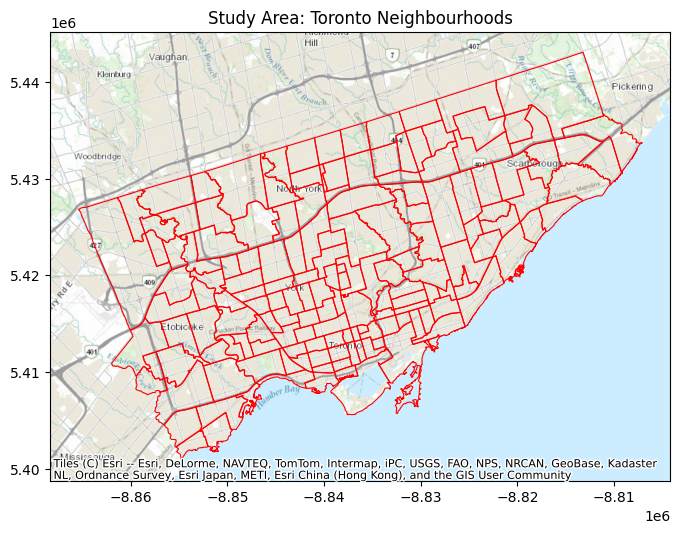

In [15]:
# -------------------------------------------
# Study area map
# -------------------------------------------

neighbourhoods = neighbourhoods.to_crs(epsg=3857)

ax = neighbourhoods.to_crs(epsg=3857).boundary.plot(
    linewidth=0.8,
    color="red",
    figsize=(8,8)
)
plt.title("Study Area: Toronto Neighbourhoods")
ctx.add_basemap(
    ax,
    crs=neighbourhoods.crs,
    source=ctx.providers.Esri.WorldTopoMap
)
plt.show()


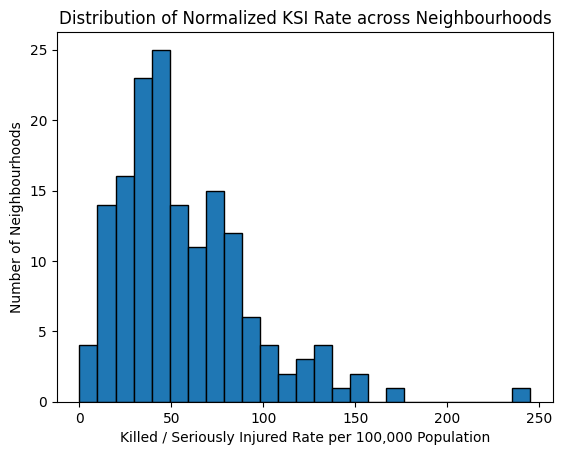

In [16]:
# -------------------------------------------
# Histogram of KSI rate
# -------------------------------------------

plt.hist(
    adt_ksi_hoods["ksi_rate"].dropna(),
    bins = 25,
    edgecolor="black",
    linewidth=1
)
plt.title("Distribution of Normalized KSI Rate across Neighbourhoods")
plt.xlabel("Killed / Seriously Injured Rate per 100,000 Population")
plt.ylabel("Number of Neighbourhoods")
plt.show()

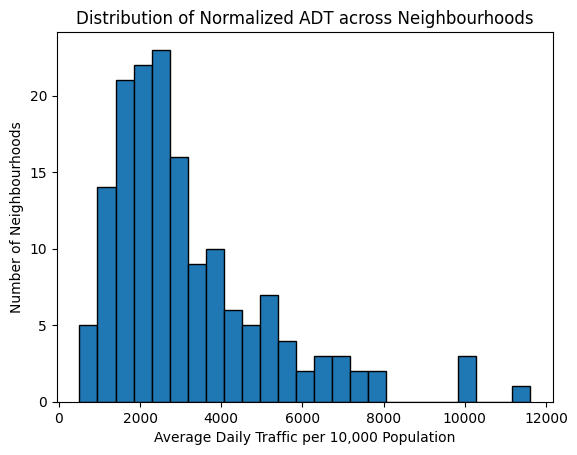

In [17]:
# -------------------------------------------
# Histogram of traffic volumes
# -------------------------------------------

plt.hist(
    adt_ksi_hoods["adt_rate"],
    bins = 25,
    edgecolor="black",
    linewidth=1
)
plt.title("Distribution of Normalized ADT across Neighbourhoods")
plt.xlabel("Average Daily Traffic per 10,000 Population")
plt.ylabel("Number of Neighbourhoods")
plt.show()

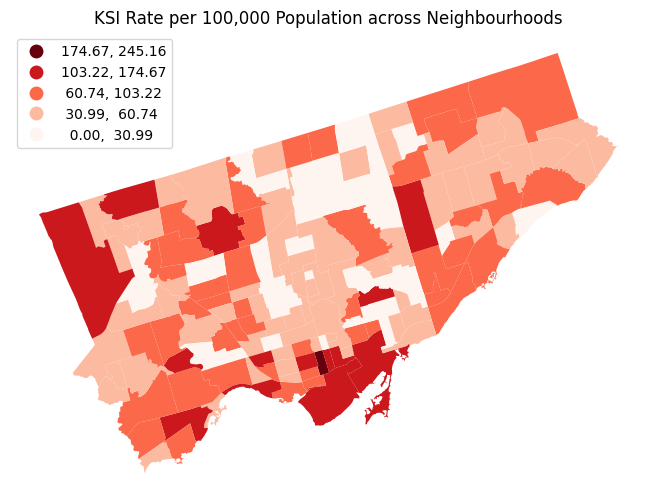

In [18]:
# --------------------------------------------------
# Choropleth map of ksi rate across neighbourhoods
# --------------------------------------------------

ax = adt_ksi_hoods.plot(
    figsize=(10,6),
    column="ksi_rate",
    scheme="natural_breaks",
    cmap="Reds",
    legend=True,
    legend_kwds={
        "loc": "upper left",
        "reverse": True
    }
)
ax.set_title("KSI Rate per 100,000 Population across Neighbourhoods")
ax.set_axis_off()
plt.show()


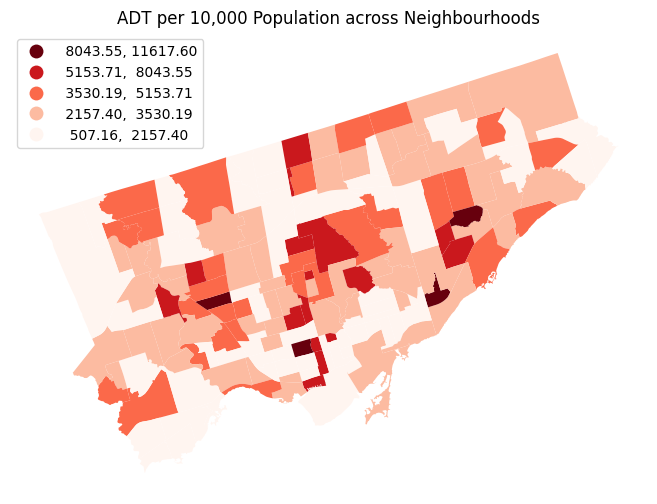

In [19]:
# -------------------------------------------------------------
# Choropleth map of traffic volumes across neighbourhoods
# -------------------------------------------------------------

ax = adt_ksi_hoods.plot(
    figsize=(10,6),
    column="adt_rate",
    scheme="natural_breaks",
    cmap="Reds",
    legend=True,
    legend_kwds={
        "loc": "upper left",
        "reverse": True
    }
)
ax.set_title("ADT per 10,000 Population across Neighbourhoods")
ax.set_axis_off()
plt.show()

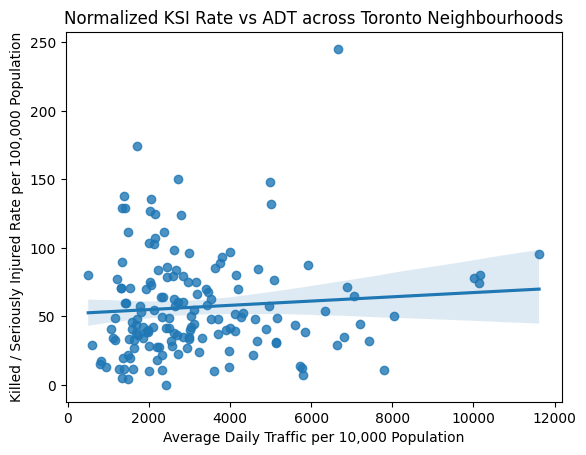

In [20]:
# -------------------------------------------
# Scatterplot of ksi vs volumes
# -------------------------------------------

sp = sns.regplot(x="adt_rate", y="ksi_rate", data=adt_ksi_hoods)
plt.title("Normalized KSI Rate vs ADT across Toronto Neighbourhoods")
plt.xlabel("Average Daily Traffic per 10,000 Population")
plt.ylabel("Killed / Seriously Injured Rate per 100,000 Population")
plt.show()

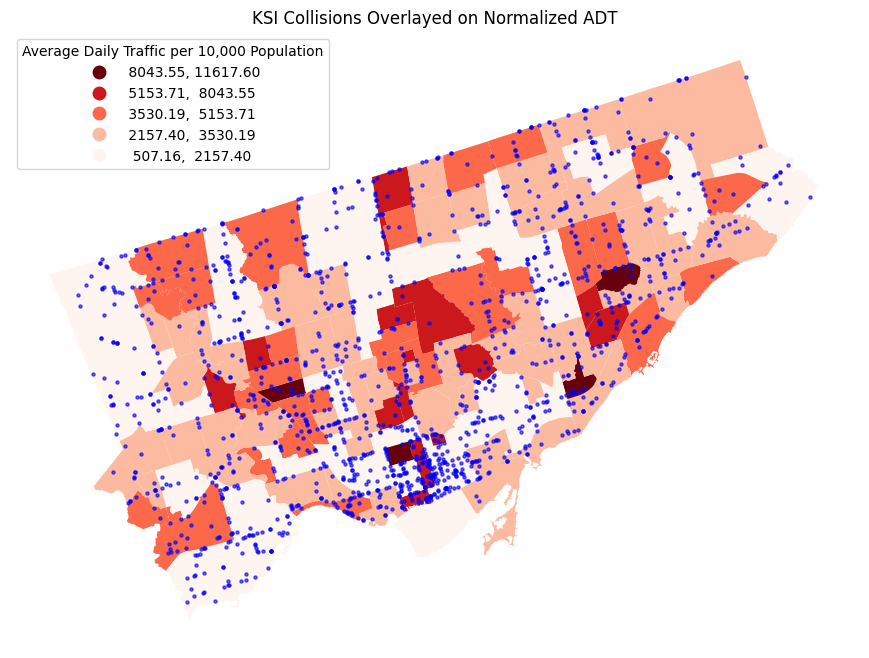

In [21]:
# -------------------------------------------
# KSI locations overlay on traffic volumes
# -------------------------------------------

fig, ax = plt.subplots(figsize=(12,8))
# Plot ADT on the figure
adt_ksi_hoods.plot(
    column="adt_rate",
    scheme="natural_breaks",
    cmap="Reds",
    legend=True,
    legend_kwds={
        "title": "Average Daily Traffic per 10,000 Population",
        "loc": "upper left",
        "reverse": True
    },
    ax=ax
)
# Plot KSI dots on the figure
ksi.plot(
    ax=ax,
    markersize=5,
    color='blue',
    alpha=0.6,
)

ax.set_title("KSI Collisions Overlayed on Normalized ADT")
ax.set_axis_off()
plt.show()

# Spatial Analysis

In [22]:
# -------------------------------------------
# Build queen continguity weights
# -------------------------------------------

w  = weights.contiguity.Queen.from_dataframe(adt_ksi_hoods)

/tmp/ipykernel_13124/3428663694.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w  = weights.contiguity.Queen.from_dataframe(adt_ksi_hoods)


In [23]:
# -------------------------------------------
# Global Moran's I
# -------------------------------------------

# For KSI rate
moran_ksi = esda.moran.Moran(adt_ksi_hoods["ksi_rate"], w)
print("Moran's I (KSI):", moran_ksi.I)
print("p-value (KSI):", moran_ksi.p_sim)

# For traffic volume
moran_adt = esda.moran.Moran(adt_ksi_hoods["adt_rate"], w)
print("Moran's I (ADT):", moran_adt.I)
print("p-value (ADT):", moran_adt.p_sim)

Moran's I (KSI): 0.14222931867748623
p-value (KSI): 0.001
Moran's I (ADT): 0.09478028438460873
p-value (ADT): 0.023


Significant proportion: 0.18354430379746836


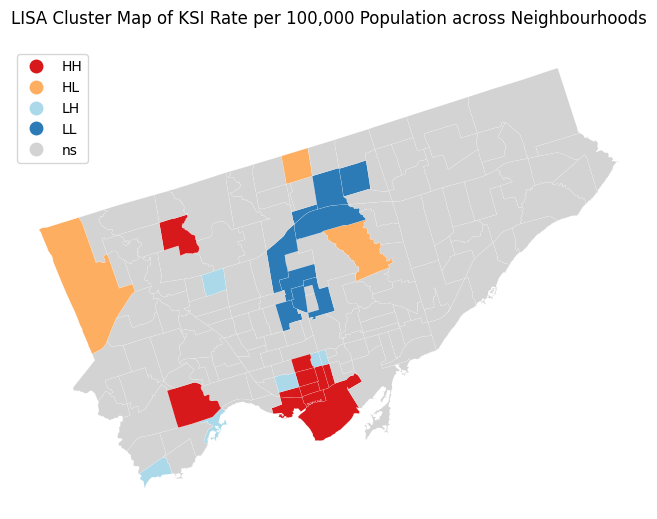

In [24]:
# -------------------------------------------
# LISA of KSI
# -------------------------------------------

# Significant proportion
lisa_ksi = esda.moran.Moran_Local(adt_ksi_hoods["ksi_rate"], w)
adt_ksi_hoods["quadrant_ksi"] = lisa_ksi.q
adt_ksi_hoods["p_sim_ksi"] = lisa_ksi.p_sim
adt_ksi_hoods["sig_ksi"] = lisa_ksi.p_sim < 0.05
print("Significant proportion:", (adt_ksi_hoods["sig_ksi"].mean()))

# LISA cluster map
adt_ksi_hoods = adt_ksi_hoods.to_crs(epsg=3857)
f, ax = plt.subplots(figsize=(10, 6))
esdaplot.lisa_cluster(lisa_ksi, adt_ksi_hoods, p=0.05, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((0,1))
legend._loc = 2
ax.set_axis_off()
ax.set_title("LISA Cluster Map of KSI Rate per 100,000 Population across Neighbourhoods")
plt.show()

Significant proportion: 0.16455696202531644


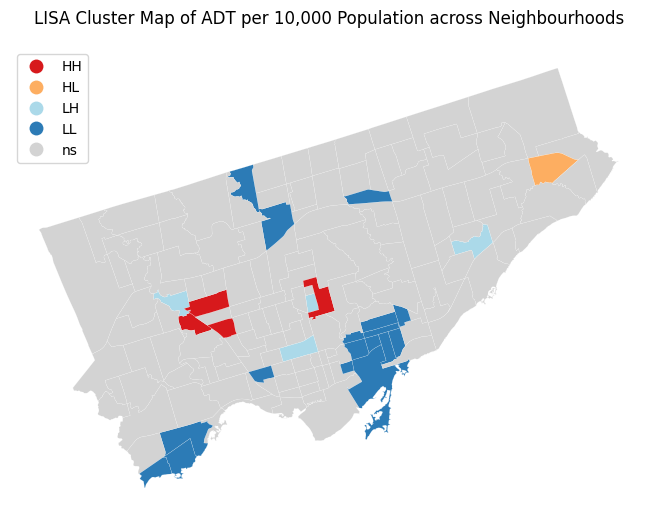

In [25]:
# -------------------------------------------
# LISA of ADT
# -------------------------------------------

# Significance proportion
lisa_adt = esda.moran.Moran_Local(adt_ksi_hoods["adt_rate"], w)
adt_ksi_hoods["quadrant_adt"] = lisa_adt.q
adt_ksi_hoods["p_sim_adt"] = lisa_adt.p_sim
adt_ksi_hoods["sig_adt"] = lisa_adt.p_sim < 0.05
print("Significant proportion:", (adt_ksi_hoods["sig_adt"].mean()))

# LISA cluster map
f, ax = plt.subplots(figsize=(10, 6))
esdaplot.lisa_cluster(lisa_adt, adt_ksi_hoods, p=0.05, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((0,1))
legend._loc = 2
ax.set_axis_off()
ax.set_title("LISA Cluster Map of ADT per 10,000 Population across Neighbourhoods")
plt.show()

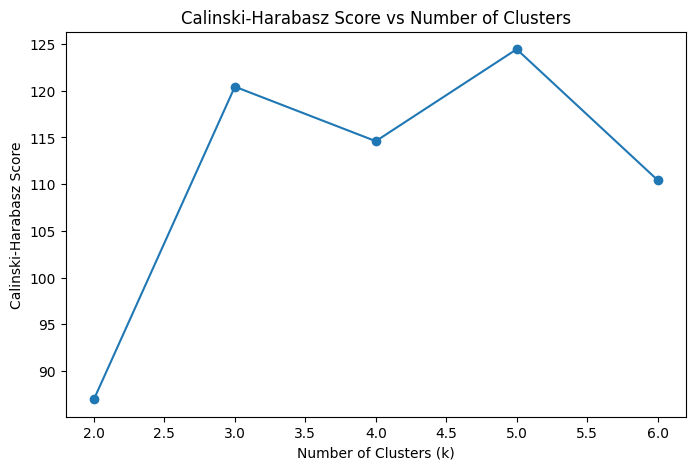

Optimal number of clusters: 5


In [26]:
# -------------------------------------------
# Standardization & Optimal k
# -------------------------------------------

# Robust scaling to reduce effect of outliers
kv = adt_ksi_hoods[["ksi_rate", "adt_rate"]].copy()
kv_scaled = robust_scale(kv)

# Determine optimal number of clusters (k)
ch_scores = []
k_range = range(2, 7)  # Test 2 to 6 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1234)
    labels = kmeans.fit_predict(kv_scaled)
    score = calinski_harabasz_score(kv_scaled, labels)
    ch_scores.append(score)

# Plot CH score to choose optimal k
plt.figure(figsize=(8,5))
plt.plot(k_range, ch_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score vs Number of Clusters")
plt.show()

# Choose k with highest CH score
optimal_k = k_range[np.argmax(ch_scores)]
print("Optimal number of clusters:", optimal_k)

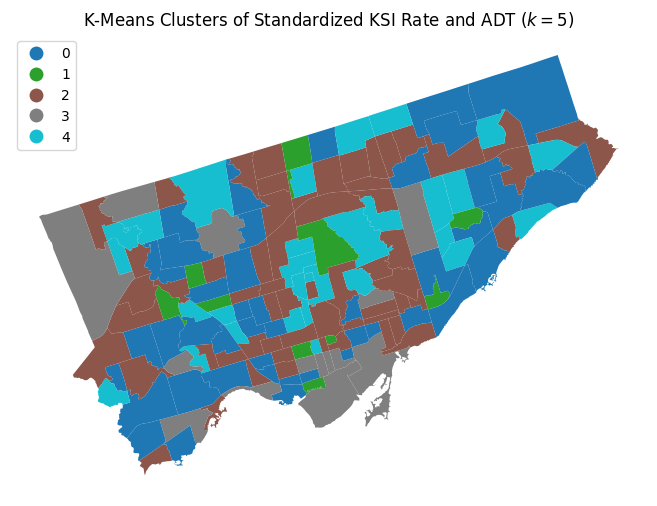

         ksi_rate     adt_rate  n_neighbourhoods
k6cls                                           
0       75.084663  2530.006540                44
1       57.919627  8465.475710                11
2       30.210416  2020.760886                59
3      141.419291  2726.478697                14
4       42.540298  4811.759239                30


In [27]:
# -------------------------------------------
# K-means clustering
# -------------------------------------------

# Run K-Means algorithm
kmeans = KMeans(n_clusters=optimal_k)
np.random.seed(1234)
k6cls = kmeans.fit(kv_scaled)

# Assign labels into a column
adt_ksi_hoods["k6cls"] = k6cls.labels_

# Plot figure
f, ax = plt.subplots(1, figsize=(10, 6))
adt_ksi_hoods.plot(
    column="k6cls",
    categorical=True,
    legend=True,
    legend_kwds={"loc": "upper left"},
    linewidth=0,
    ax=ax
)
ax.set_title("K-Means Clusters of Standardized KSI Rate and ADT ($k=5$)")
ax.set_axis_off()
plt.show()

# Create cluster profiles
k6cls_profiles = adt_ksi_hoods.groupby("k6cls").agg({
    "ksi_rate": "mean",
    "adt_rate": "mean",
    "k6cls": "count"   # count number of neighbourhoods
})
k6cls_profiles = k6cls_profiles.rename(columns={
    "k6cls": "n_neighbourhoods"
})
print(k6cls_profiles)

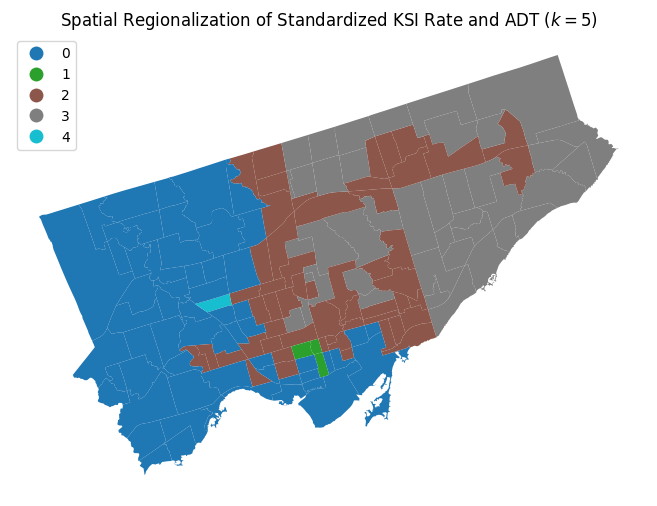

           ksi_rate      adt_rate  n_neighbourhoods
ward6wq                                            
0         75.766583   2968.447464                59
1        125.615156   7669.070740                 3
2         32.541737   2193.460066                54
3         55.589275   4340.947115                41
4         95.846645  11617.603834                 1


In [28]:
# -------------------------------------------
# Spatial regionalization
# -------------------------------------------

# Agglomerative clustering with spatial constraint
np.random.seed(123456)
model = AgglomerativeClustering(
    linkage="ward", connectivity=w.sparse, n_clusters=optimal_k
)

# Fit algorithm to the data
model.fit(kv_scaled)
adt_ksi_hoods["ward6wq"] = model.labels_

# Plot figure
f, ax = plt.subplots(1, figsize=(10, 6))
adt_ksi_hoods.plot(
    column="ward6wq",
    categorical=True,
    legend=True,
    legend_kwds={"loc": "upper left"},
    linewidth=0,
    ax=ax,
)
ax.set_title("Spatial Regionalization of Standardized KSI Rate and ADT ($k=5$)")
ax.set_axis_off()
plt.show()

# Create cluster profiles
ward6wq_profiles = adt_ksi_hoods.groupby("ward6wq").agg({
    "ksi_rate": "mean",
    "adt_rate": "mean",
    "ward6wq": "count"   # count number of neighbourhoods
})
ward6wq_profiles = ward6wq_profiles.rename(columns={
    "ward6wq": "n_neighbourhoods"
})
print(ward6wq_profiles)
